# Sentiment Analysis 

This notebook implements sentiment analysis, to assign a numeric value to the sentiment of comments. 

In [1]:
import numpy as np
import regex

from transformers import BertTokenizerFast, pipeline

from database.comments import Comments

import sys
sys.path.append('../pipeline')
from nlp_tasks import NLP_Tasks

/opt/conda/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Can use the sentiment analysis pipeline from HuggingFace

In [2]:
cs = Comments(env='dev')
nlp = NLP_Tasks()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


Device set to use cpu
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


In [3]:
df = cs.read_all()
df = df
print('df shape:', df.shape)

df shape: (30393, 14)


In [4]:
sentiment_model = pipeline(model="finiteautomata/bertweet-base-sentiment-analysis")

def split_period_or_length(comment, max_length=100):
    sentences = regex.split(r'(?<=[.!?]) +', comment)
    split_sentences = []
    for sentence in sentences:
        if len(sentence) > max_length:
            # Split long sentences into smaller chunks
            for i in range(0, len(sentence), max_length):
                split_sentences.append(sentence[i:i + max_length])
        else:
            split_sentences.append(sentence)
    return split_sentences

def sentiment_score(comment, stance):
    
    # Split the comment into sentences
    # sentences = regex.split(r'(?<=[.!?]) +', comment)
    sentences = split_period_or_length(comment, max_length=100)
    n = len(sentences)

    # Analyse sentiment for each sentence
    sentiment_results = sentiment_model(sentences)

    # Calculate score by adding 'POS' scores and subtracting 'NEG' scores
    score = 0
    for result in sentiment_results:
        if result['label'] == 'POS':
            score += result['score']
        elif result['label'] == 'NEG':
            score -= result['score']

    score = float(score / n)

    # Adjust score based on stance
    if stance == 'Objects' and score > 0:
        score = 0
    elif stance == 'Supports' and score < 0:
        score = 0

    return score

Device set to use cpu


### Practise sentiment scoring 

In [5]:
sentiment_model = pipeline(model="finiteautomata/bertweet-base-sentiment-analysis")

id = df['comment_id'][3]
comment = df['cleaned_comment_text'][3]
stance = df['stance'][3]
score = nlp.sentiment_score(comment, stance, sentiment_model)

cs.update_sentiment_score_by_comment_id(id, score)

Device set to use cpu


Successfully updated sentiment_score for comment_id 230449FUL_3: -0.09630183228906596


True

In [6]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,93852,Barnet,23/5296/FUL_4,23/5296/FUL,56 Salisbury Road London EN5 4JN,Objects,2024-01-08,The proposed change of use would result in the...,2025-04-11,51.655520,-0.206390,The proposed change of use would result in the...,E09000003,-0.331333
1,80520,Ealing,215058FULR3_71,215058FULR3,7 Lady Margaret Road Southall UB1 2PJ UB1 2PJ,Objects,2021-08-29,I feel no further flats should be made in Sout...,2025-04-09,51.512290,-0.375790,I feel no further flats should be made in beca...,E09000009,-0.433537
2,90711,Ealing,230449FUL_2,230449FUL,42 Wimborne Gardens Ealing W13 8BZ W13 8BZ,Objects,2023-03-13,Please note that:\nA. The Appendices with phot...,2025-04-10,51.520690,-0.317070,Please note that:\n. The Appendices with photo...,E09000009,0.000000
3,90712,Ealing,230449FUL_3,230449FUL,12 Cleveland Road 12 Cleveland Road London W13...,Objects,2023-03-11,I wish to object to the proposed development o...,2025-04-10,51.521510,-0.317170,I wish to object to the proposed development o...,E09000009,-0.096302
4,92045,Ealing,215983FUL_309,215983FUL,19 Jessamine Road London W7 3SQ W7 3SQ,Objects,2021-11-13,I live on an Adjacent road. This proposal will...,2025-04-10,51.508023,-0.336863,I live on an Adjacent road. This proposal will...,None,-0.305609


In [7]:
# sns colour palette for stance 
stance_palette = {
    'Supports': '#5B76BD',  # blue
    'Objects': '#B04F2C',   # orange
    'Neutral': '#82B02C'    # green
}

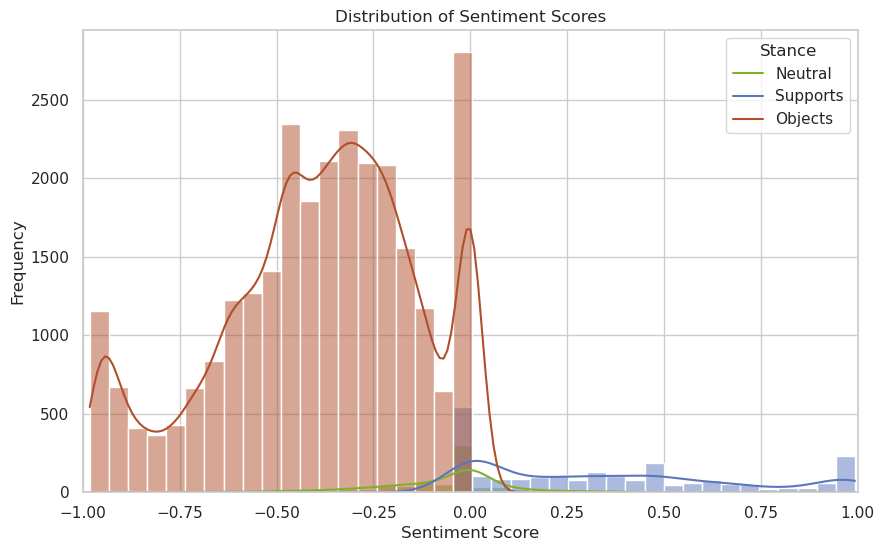

In [8]:
# Plot histogram of sentiment scores
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")  
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="sentiment_score", bins=40, kde=True, hue="stance", legend=True, palette=stance_palette)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.xlim(-1, 1)
plt.legend(title='Stance', loc='upper right', labels=['Neutral', 'Supports', 'Objects'])
# plt.axvline(x=0, color='red', linestyle='--', label='Neutral')
# plt.legend()
plt.show()